## **Modelado predictivo**

**0. Configuración experimental**

Durante esta fase se utilizará una estrategia de clasificación binaria supervisada para predecir la ocurrencia de siniestros fatales.

Para garantizar la reproducibilidad de los resultados, todos los experimentos utilizarán `random_state=42` cuando el algoritmo o procedimiento lo permita.

La clase positiva será:

- `1` = siniestro fatal

La clase negativa será:

- `0` = siniestro no fatal

Debido al fuerte desbalance de clases identificado en las fases anteriores, la evaluación del desempeño priorizará las métricas Recall y F1-Score para la clase positiva, complementadas por Precision y Accuracy.

**1. Definición del problema y carga del dataset**

En esta fase se construirá un modelo de clasificación binaria para estimar si un siniestro vial tuvo víctimas fatales.

La variable objetivo será `siniestro_fatal`, donde:

- `1` representa un siniestro fatal.
- `0` representa un siniestro no fatal.

El modelado se realizará a nivel siniestro, manteniendo la unidad de análisis definida en las fases anteriores.

In [1]:
# Importación de librerías principales

import pandas as pd
import numpy as np

# Configuración general de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# Carga del dataset analítico generado en la fase de ETL

ruta_dataset = "../data_processed/siniestros_viales_modelado.csv"

df = pd.read_csv(ruta_dataset)

df.head()

C:\Users\consul_05\AppData\Local\Temp\ipykernel_332\1200171924.py:5: DtypeWarning: Columns (7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(ruta_dataset)


,id_siniestro,siniestro_fatal,fecha_siniestro,anio_siniestro,mes_siniestro,dia_siniestro,dia_semana,rango_horario,comuna_siniestro,tipo_de_via_siniestro,participantes_siniestro,modo_desplazamiento_victima,contraparte_siniestro,latitud_siniestro,longitud_siniestro,edad_promedio_victimas,sexo_victima_agregado
0,LC-2019-0000053,0,2019-01-01,2019,1,1,Tuesday,1.0,8.0,AUTOPISTA,AUTO-UTILITARIO,AUTO,UTILITARIO,-34.669125,-58.443510,57.000000,M
1,LC-2019-0000647,0,2019-01-01,2019,1,1,Tuesday,18.0,12.0,AVENIDA,MOTO-AUTO,MOTO,AUTO,-34.583403,-58.490436,54.000000,M
2,LC-2019-0000445,0,2019-01-01,2019,1,1,Tuesday,13.0,11.0,NaN,AUTO-AUTO,AUTO,AUTO,-34.603255,-58.524662,40.333333,MIXTO
3,LC-2019-0000194,0,2019-01-01,2019,1,1,Tuesday,7.0,9.0,NaN,AUTO-CAMION,AUTO,CAMION,-34.650156,-58.528413,33.000000,F
4,LC-2019-0000329,0,2019-01-01,2019,1,1,Tuesday,12.0,4.0,NaN,AUTO-MOVIL,AUTO,MOVIL,-34.648387,-58.404748,23.000000,M


El dataset se carga desde el archivo consolidado generado en las fases anteriores. Se especifican los tipos de datos de `rango_horario` y `comuna_siniestro` para evitar advertencias de tipos mixtos y conservar su tratamiento como variables categóricas durante el modelado.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65818 entries, 0 to 65817
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id_siniestro                 65818 non-null  object 
 1   siniestro_fatal              65818 non-null  int64  
 2   fecha_siniestro              65818 non-null  object 
 3   anio_siniestro               65818 non-null  int64  
 4   mes_siniestro                65818 non-null  int64  
 5   dia_siniestro                65818 non-null  int64  
 6   dia_semana                   65818 non-null  object 
 7   rango_horario                65741 non-null  object 
 8   comuna_siniestro             62801 non-null  object 
 9   tipo_de_via_siniestro        53591 non-null  object 
 10  participantes_siniestro      65818 non-null  object 
 11  modo_desplazamiento_victima  65818 non-null  object 
 12  contraparte_siniestro        65818 non-null  object 
 13  latitud_siniestr

A partir del dataset analítico generado en las fases anteriores se definen la variable objetivo y las variables predictoras que serán utilizadas en los modelos de clasificación.

Se excluyen aquellas variables que podrían generar fuga de información (data leakage) o que fueron descartadas durante las etapas de ETL y EDA.

La variable objetivo del modelo es `siniestro_fatal`, construida previamente a nivel siniestro.

Se utilizarán como variables predictoras aquellas que describen características temporales, geográficas y de participantes del siniestro. No se incluyen variables que describen consecuencias posteriores del hecho, como cantidad de víctimas fatales, gravedad del siniestro o fecha de fallecimiento, ya que podrían generar fuga de información.

Esta decisión busca construir un modelo defendible, donde las variables utilizadas representen información explicativa disponible para el análisis y no información directamente derivada del resultado que se intenta predecir.

In [4]:
# Variable objetivo

y = df["siniestro_fatal"]

# Variables predictoras

X = df[
    [
        "anio_siniestro",
        "mes_siniestro",
        "dia_siniestro",
        "dia_semana",
        "rango_horario",
        "comuna_siniestro",
        "tipo_de_via_siniestro",
        "participantes_siniestro",
        "modo_desplazamiento_victima",
        "contraparte_siniestro",
        "latitud_siniestro",
        "longitud_siniestro",
        "edad_promedio_victimas",
        "sexo_victima_agregado"
    ]
]

print(f"Registros: {X.shape[0]}")
print(f"Variables predictoras: {X.shape[1]}")

Registros: 65818
Variables predictoras: 14


Se definió `siniestro_fatal` como variable objetivo y se seleccionaron 14 variables predictoras. La selección excluye identificadores, fechas completas y variables asociadas directamente a la gravedad o al resultado del siniestro, para evitar fuga de información.

In [6]:
# Distribución de la variable objetivo

distribucion_objetivo = pd.DataFrame({
    "cantidad": y.value_counts(),
    "porcentaje": round(y.value_counts(normalize=True) * 100, 2)
})

distribucion_objetivo

,cantidad,porcentaje
siniestro_fatal,,
0,65129,98.95
1,689,1.05


**Observaciones**
La distribución observada confirma un fuerte desbalance de clases.

- Siniestros no fatales: 65.129 registros (98,95%).
- Siniestros fatales: 689 registros (1,05%).

Esta situación requiere especial atención durante el modelado, ya que métricas como Accuracy pueden resultar engañosas. Por este motivo se priorizarán métricas como Recall y F1-Score para la clase positiva y se utilizarán estrategias específicas para mitigar el desbalance, como particiones estratificadas y ponderación de clases.

### **2. Construcción del pipeline de preprocesamiento**

Para evitar fuga de información y garantizar que las mismas transformaciones se apliquen tanto a los datos de entrenamiento como a los de prueba, se utilizarán pipelines de preprocesamiento.

Las variables numéricas serán imputadas mediante mediana y escaladas cuando corresponda. Las variables categóricas serán imputadas mediante una categoría específica para faltantes y transformadas mediante One Hot Encoding.

In [7]:
# Herramientas de preprocesamiento

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Variables numéricas

variables_numericas = [
    "latitud_siniestro",
    "longitud_siniestro",
    "edad_promedio_victimas"
]

# Variables categóricas

variables_categoricas = [
    "anio_siniestro",
    "mes_siniestro",
    "dia_siniestro",
    "dia_semana",
    "rango_horario",
    "comuna_siniestro",
    "tipo_de_via_siniestro",
    "participantes_siniestro",
    "modo_desplazamiento_victima",
    "contraparte_siniestro",
    "sexo_victima_agregado"
]

# Pipeline numérico

pipeline_numerico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Pipeline categórico

pipeline_categorico = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="SIN_DATO")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# Preprocesador general

preprocessor = ColumnTransformer(
    transformers=[
        ("num", pipeline_numerico, variables_numericas),
        ("cat", pipeline_categorico, variables_categoricas)
    ]
)

preprocessor

,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'median'
,fill_value,None


Se construyó un pipeline de preprocesamiento que aplica transformaciones diferentes según el tipo de variable.

Las variables numéricas serán imputadas mediante la mediana y posteriormente escaladas. Las variables categóricas serán imputadas mediante una categoría específica para faltantes y transformadas mediante One Hot Encoding.

Este enfoque permite aplicar exactamente las mismas transformaciones a los datos de entrenamiento y prueba, evitando inconsistencias durante el modelado y reduciendo el riesgo de fuga de información.

### **3. División de los datos**

Antes de entrenar los modelos se separan los datos en conjuntos de entrenamiento y prueba.

Dado el fuerte desbalance de clases identificado anteriormente, se utilizará una partición estratificada para conservar la proporción de siniestros fatales y no fatales en ambos conjuntos.

In [9]:
from sklearn.model_selection import train_test_split

# División entrenamiento / prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (52654, 14)
X_test : (13164, 14)
y_train: (52654,)
y_test : (13164,)


Los datos fueron divididos en conjuntos de entrenamiento y prueba utilizando una proporción 80/20.

Dado el fuerte desbalance de la variable objetivo, se utilizó una partición estratificada para preservar la misma proporción de siniestros fatales y no fatales en ambos conjuntos.

Esta estrategia permite obtener una evaluación más representativa del desempeño real de los modelos.

In [10]:
# Validación de la estratificación

distribucion_train = round(y_train.value_counts(normalize=True) * 100, 2)
distribucion_test = round(y_test.value_counts(normalize=True) * 100, 2)

print("Distribución entrenamiento (%)")
print(distribucion_train)

print("\nDistribución prueba (%)")
print(distribucion_test)

Distribución entrenamiento (%)
siniestro_fatal
0    98.95
1     1.05
Name: proportion, dtype: float64

Distribución prueba (%)
siniestro_fatal
0    98.95
1     1.05
Name: proportion, dtype: float64


La distribución de clases se mantuvo sin cambios entre los conjuntos de entrenamiento y prueba.

- Entrenamiento: 98,95% no fatales y 1,05% fatales.
- Prueba: 98,95% no fatales y 1,05% fatales.

Esto confirma que la estratificación se realizó correctamente y que ambos conjuntos representan adecuadamente la distribución original del problema.

### **4. Modelo baseline**

Antes de entrenar modelos predictivos más complejos, se construirá un modelo baseline utilizando un Dummy Classifier.

Este modelo no aprende patrones de los datos y sirve como referencia mínima de desempeño. Su objetivo es verificar posteriormente si los modelos entrenados realmente aportan capacidad predictiva respecto de una estrategia trivial.

In [11]:
# Modelo baseline

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

# Entrenamiento

dummy_model = DummyClassifier(
    strategy="most_frequent"
)

dummy_model.fit(X_train, y_train)

# Predicciones

y_pred_dummy = dummy_model.predict(X_test)

# Métricas

accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
precision_dummy = precision_score(y_test, y_pred_dummy, zero_division=0)
recall_dummy = recall_score(y_test, y_pred_dummy, zero_division=0)
f1_dummy = f1_score(y_test, y_pred_dummy, zero_division=0)

print(f"Accuracy : {accuracy_dummy:.4f}")
print(f"Precision: {precision_dummy:.4f}")
print(f"Recall   : {recall_dummy:.4f}")
print(f"F1-Score : {f1_dummy:.4f}")

Accuracy : 0.9895
Precision: 0.0000
Recall   : 0.0000
F1-Score : 0.0000


El modelo baseline obtuvo una Accuracy de 98,95%, valor que inicialmente podría interpretarse como un muy buen desempeño.

Sin embargo, las métricas Precision, Recall y F1-Score resultaron iguales a cero. Esto ocurre porque el Dummy Classifier predice siempre la clase mayoritaria (siniestro no fatal) y nunca identifica correctamente un siniestro fatal.

Este resultado evidencia el impacto del fuerte desbalance de clases presente en el problema y demuestra que la Accuracy, por sí sola, no es una métrica adecuada para evaluar el desempeño del modelo.

A partir de este punto se priorizarán especialmente las métricas Recall y F1-Score para la clase positiva, ya que permiten medir la capacidad real de detectar siniestros fatales.

### **5. Entrenamiento de modelos iniciales**

Se entrenarán tres algoritmos de clasificación utilizando exactamente el mismo conjunto de entrenamiento y el mismo pipeline de preprocesamiento.

Los modelos seleccionados representan distintos enfoques de aprendizaje:

- Logistic Regression.
- Decision Tree Classifier.
- Random Forest Classifier.

Posteriormente se compararán sus métricas sobre el conjunto de prueba para identificar los candidatos más prometedores.

In [12]:
# Modelos de clasificación

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [13]:
# Conversión de variables categóricas a texto

for col in variables_categoricas:
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

Durante las validaciones previas al entrenamiento se detectaron diferencias de tipo de dato en algunas variables categóricas, producto de valores faltantes y transformaciones realizadas en etapas anteriores.

Para garantizar la compatibilidad con One Hot Encoding, todas las variables categóricas fueron convertidas explícitamente a tipo texto antes del entrenamiento de los modelos.

In [14]:
# Logistic Regression

pipeline_logistic = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

pipeline_logistic.fit(X_train, y_train)

y_pred_logistic = pipeline_logistic.predict(X_test)

In [15]:
# Decision Tree

pipeline_tree = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

pipeline_tree.fit(X_train, y_train)

y_pred_tree = pipeline_tree.predict(X_test)

In [16]:
# Random Forest

pipeline_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

pipeline_forest.fit(X_train, y_train)

y_pred_forest = pipeline_forest.predict(X_test)

Se entrenaron tres algoritmos de clasificación utilizando el mismo conjunto de entrenamiento y el mismo pipeline de preprocesamiento.

De esta manera, cualquier diferencia observada posteriormente en las métricas podrá atribuirse al comportamiento propio de cada algoritmo y no a diferencias en la preparación de los datos.

### **6. Comparación inicial de modelos**

Una vez entrenados los modelos iniciales, se comparan sus métricas sobre el conjunto de prueba.

La comparación incluye el modelo baseline para evaluar si los modelos entrenados mejoran respecto de una estrategia trivial.

In [17]:
# Comparación de métricas

resultados_modelos = pd.DataFrame([
    {
        "modelo": "Dummy Classifier",
        "accuracy": accuracy_dummy,
        "precision": precision_dummy,
        "recall": recall_dummy,
        "f1_score": f1_dummy
    },
    {
        "modelo": "Logistic Regression",
        "accuracy": accuracy_score(y_test, y_pred_logistic),
        "precision": precision_score(y_test, y_pred_logistic, zero_division=0),
        "recall": recall_score(y_test, y_pred_logistic, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_logistic, zero_division=0)
    },
    {
        "modelo": "Decision Tree",
        "accuracy": accuracy_score(y_test, y_pred_tree),
        "precision": precision_score(y_test, y_pred_tree, zero_division=0),
        "recall": recall_score(y_test, y_pred_tree, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_tree, zero_division=0)
    },
    {
        "modelo": "Random Forest",
        "accuracy": accuracy_score(y_test, y_pred_forest),
        "precision": precision_score(y_test, y_pred_forest, zero_division=0),
        "recall": recall_score(y_test, y_pred_forest, zero_division=0),
        "f1_score": f1_score(y_test, y_pred_forest, zero_division=0)
    }
])

resultados_modelos.sort_values(by="f1_score", ascending=False)

,modelo,accuracy,precision,recall,f1_score
2,Decision Tree,0.979793,0.104938,0.123188,0.113333
1,Logistic Regression,0.867669,0.057883,0.760870,0.107582
0,Dummy Classifier,0.989517,0.000000,0.000000,0.000000
3,Random Forest,0.989517,0.000000,0.000000,0.000000


Los resultados muestran comportamientos muy diferentes entre los modelos evaluados.

El Dummy Classifier y Random Forest obtuvieron una Accuracy cercana al 99%, pero no lograron identificar ningún siniestro fatal, obteniendo valores nulos en Precision, Recall y F1-Score.

Por el contrario, Logistic Regression y Decision Tree sí lograron detectar siniestros fatales, aunque con estrategias diferentes. Logistic Regression obtuvo el mayor Recall, mientras que Decision Tree alcanzó el mejor F1-Score gracias a un equilibrio más favorable entre Precision y Recall.

Estos resultados refuerzan la importancia de utilizar métricas adecuadas para problemas desbalanceados, ya que la Accuracy por sí sola no refleja la capacidad real de detectar la clase minoritaria.

In [18]:
# Cantidad de predicciones positivas

print("Dummy:", y_pred_dummy.sum())
print("Logistic:", y_pred_logistic.sum())
print("Decision Tree:", y_pred_tree.sum())
print("Random Forest:", y_pred_forest.sum())

Dummy: 0
Logistic: 1814
Decision Tree: 162
Random Forest: 0


**Análisis inicial de resultados**

La comparación de métricas evidencia que los modelos no responden de la misma manera frente al fuerte desbalance de clases presente en el problema.

Mientras que Logistic Regression prioriza la detección de siniestros fatales, generando una gran cantidad de predicciones positivas, Decision Tree adopta una estrategia más conservadora y obtiene un mejor equilibrio entre Precision y Recall.

Por otro lado, Random Forest no logró identificar ningún siniestro fatal en su configuración inicial, obteniendo un comportamiento equivalente al modelo baseline.

Considerando que el objetivo principal del proyecto es detectar siniestros fatales, los modelos Logistic Regression y Decision Tree serán seleccionados como candidatos para la etapa de optimización de hiperparámetros.

### **7. Optimización de hiperparámetros**

Una vez identificados los modelos con mejor desempeño inicial, se realizará una búsqueda sistemática de hiperparámetros utilizando validación cruzada.

El objetivo es mejorar la capacidad predictiva de los modelos sin modificar el conjunto de datos ni el pipeline de preprocesamiento.

**Logistic Regression**

In [19]:
from sklearn.model_selection import GridSearchCV

# Búsqueda de hiperparámetros para Logistic Regression

pipeline_logistic_gs = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

param_grid_logistic = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

grid_logistic = GridSearchCV(
    estimator=pipeline_logistic_gs,
    param_grid=param_grid_logistic,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_logistic.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_logistic.best_params_)

print("\nMejor F1 CV:")
print(round(grid_logistic.best_score_, 4))

Mejores parámetros:
{'model__C': 1, 'model__solver': 'lbfgs'}

Mejor F1 CV:
0.1157


La búsqueda de hiperparámetros identificó como mejor configuración una Logistic Regression con `C=1` y solver `lbfgs`.

El mejor F1-Score promedio obtenido mediante validación cruzada fue 0,1157, valor ligeramente superior al alcanzado por la configuración inicial. Esto sugiere que el modelo presenta una mejora moderada y que la configuración utilizada originalmente ya se encontraba próxima a una solución adecuada dentro del espacio de búsqueda evaluado.

In [20]:
# Evaluación de la mejor Logistic Regression

best_logistic = grid_logistic.best_estimator_

y_pred_logistic_best = best_logistic.predict(X_test)

accuracy_logistic_best = accuracy_score(y_test, y_pred_logistic_best)
precision_logistic_best = precision_score(y_test, y_pred_logistic_best, zero_division=0)
recall_logistic_best = recall_score(y_test, y_pred_logistic_best, zero_division=0)
f1_logistic_best = f1_score(y_test, y_pred_logistic_best, zero_division=0)

print(f"Accuracy : {accuracy_logistic_best:.4f}")
print(f"Precision: {precision_logistic_best:.4f}")
print(f"Recall   : {recall_logistic_best:.4f}")
print(f"F1-Score : {f1_logistic_best:.4f}")

Accuracy : 0.8677
Precision: 0.0579
Recall   : 0.7609
F1-Score : 0.1076


El desempeño obtenido sobre el conjunto de prueba coincide con el observado en la configuración inicial del modelo.

Esto se explica porque la búsqueda de hiperparámetros seleccionó los mismos valores utilizados por defecto en Logistic Regression (`C=1` y `solver='lbfgs'`), por lo que no se produjeron cambios en las predicciones finales.

Este resultado indica que, dentro del espacio de búsqueda evaluado, la configuración inicial ya representaba la mejor alternativa para este modelo.

**Decision Tree**

In [22]:
# Búsqueda de hiperparámetros para Decision Tree

pipeline_tree_gs = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

param_grid_tree = {
    "model__max_depth": [3, 5, 10, 15, None],
    "model__min_samples_split": [2, 10, 50],
    "model__min_samples_leaf": [1, 5, 20]
}

grid_tree = GridSearchCV(
    estimator=pipeline_tree_gs,
    param_grid=param_grid_tree,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_tree.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_tree.best_params_)

print("\nMejor F1 CV:")
print(round(grid_tree.best_score_, 4))

Mejores parámetros:
{'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 2}

Mejor F1 CV:
0.1465


La optimización de hiperparámetros produjo una mejora significativa respecto del árbol inicial, alcanzando un F1-Score promedio de 0,1465 mediante validación cruzada.

La mejor configuración encontrada permite que el árbol crezca sin límite de profundidad, pero exige un mínimo de 5 observaciones por hoja. Esto sugiere que la mejora del modelo proviene principalmente de una reducción del sobreajuste local generado por hojas demasiado pequeñas.

In [23]:
# Evaluación del mejor Decision Tree

best_tree = grid_tree.best_estimator_

y_pred_tree_best = best_tree.predict(X_test)

accuracy_tree_best = accuracy_score(y_test, y_pred_tree_best)
precision_tree_best = precision_score(y_test, y_pred_tree_best, zero_division=0)
recall_tree_best = recall_score(y_test, y_pred_tree_best, zero_division=0)
f1_tree_best = f1_score(y_test, y_pred_tree_best, zero_division=0)

print(f"Accuracy : {accuracy_tree_best:.4f}")
print(f"Precision: {precision_tree_best:.4f}")
print(f"Recall   : {recall_tree_best:.4f}")
print(f"F1-Score : {f1_tree_best:.4f}")

Accuracy : 0.9672
Precision: 0.1070
Recall   : 0.2899
F1-Score : 0.1562


La optimización de hiperparámetros permitió mejorar el desempeño del Decision Tree tanto en validación cruzada como sobre el conjunto de prueba.

El modelo incrementó su F1-Score desde 0,1133 hasta 0,1562, manteniendo un equilibrio más favorable entre Precision y Recall que el observado en Logistic Regression.

Hasta este punto, el árbol de decisión optimizado constituye el modelo con mejor desempeño global según la métrica principal definida para el proyecto.

**Random Forest**

Los resultados obtenidos hasta el momento muestran que Logistic Regression y Decision Tree lograron identificar siniestros fatales, mientras que Random Forest presentó un comportamiento equivalente al modelo baseline, sin detectar ningún caso positivo.

Sin embargo, antes de descartar definitivamente este algoritmo, se considera conveniente realizar una búsqueda de hiperparámetros. Los modelos basados en ensambles suelen ser sensibles a configuraciones como la profundidad de los árboles, la cantidad de estimadores y el tamaño mínimo de las hojas, por lo que una configuración inicial poco adecuada puede limitar significativamente su desempeño.

Por este motivo se realizará una optimización mediante GridSearchCV para verificar si Random Forest puede mejorar su capacidad de detección de la clase minoritaria y competir con los modelos candidatos seleccionados previamente.

In [24]:
# Búsqueda de hiperparámetros para Random Forest

pipeline_forest_gs = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

param_grid_forest = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [5, 10, None],
    "model__min_samples_leaf": [1, 5, 10]
}

grid_forest = GridSearchCV(
    estimator=pipeline_forest_gs,
    param_grid=param_grid_forest,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_forest.fit(X_train, y_train)

print("Mejores parámetros:")
print(grid_forest.best_params_)

print("\nMejor F1 CV:")
print(round(grid_forest.best_score_, 4))

Mejores parámetros:
{'model__max_depth': None, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}

Mejor F1 CV:
0.2483


La optimización de hiperparámetros produjo una mejora sustancial en el desempeño de Random Forest respecto de la configuración inicial.

Mientras que el modelo base no logró identificar ningún siniestro fatal, la búsqueda sistemática de hiperparámetros alcanzó un F1-Score promedio de 0,2483 mediante validación cruzada, superando ampliamente a los modelos optimizados previamente.

Este resultado evidencia la sensibilidad de los métodos de ensamble a la configuración de sus hiperparámetros y justifica la realización de procesos de optimización antes de descartar un algoritmo por su desempeño inicial.

In [25]:
# Evaluación del mejor Random Forest

best_forest = grid_forest.best_estimator_

y_pred_forest_best = best_forest.predict(X_test)

accuracy_forest_best = accuracy_score(y_test, y_pred_forest_best)
precision_forest_best = precision_score(y_test, y_pred_forest_best, zero_division=0)
recall_forest_best = recall_score(y_test, y_pred_forest_best, zero_division=0)
f1_forest_best = f1_score(y_test, y_pred_forest_best, zero_division=0)

print(f"Accuracy : {accuracy_forest_best:.4f}")
print(f"Precision: {precision_forest_best:.4f}")
print(f"Recall   : {recall_forest_best:.4f}")
print(f"F1-Score : {f1_forest_best:.4f}")

Accuracy : 0.9808
Precision: 0.1714
Recall   : 0.2174
F1-Score : 0.1917


La optimización de hiperparámetros permitió transformar un modelo inicialmente incapaz de detectar siniestros fatales en el algoritmo con mejor desempeño global del proyecto.

El Random Forest optimizado alcanzó un F1-Score de 0,1917 sobre el conjunto de prueba, superando tanto a Logistic Regression como a Decision Tree optimizado.

Desde una perspectiva práctica, Logistic Regression logró detectar una mayor cantidad de siniestros fatales (Recall más alto), pero generó una gran cantidad de falsas alarmas. En otras palabras, tendía a clasificar muchos casos como fatales, incluso cuando no lo eran.

Por el contrario, Random Forest detectó una menor cantidad de siniestros fatales, pero cuando el modelo indicaba que un siniestro era fatal, acertaba con una frecuencia considerablemente mayor. Este mejor equilibrio entre Precision y Recall explica su superioridad en términos de F1-Score y justifica su selección como modelo candidato para la evaluación final.

### **9. Evaluación final del modelo seleccionado (Random Forest optimizado)**

Luego de comparar los modelos entrenados y sus versiones optimizadas, se seleccionó Random Forest optimizado como modelo final del proyecto por haber obtenido el mejor F1-Score sobre el conjunto de prueba.

A continuación se realiza una evaluación detallada del modelo mediante un reporte de clasificación y una matriz de confusión con el objetivo de analizar su capacidad para identificar siniestros fatales y comprender los errores de clasificación cometidos.

In [26]:
# Classification reporte (Reporte de clasificación) - Random Forest optimizado

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_forest_best
    )
)

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     13026
           1       0.17      0.22      0.19       138

    accuracy                           0.98     13164
   macro avg       0.58      0.60      0.59     13164
weighted avg       0.98      0.98      0.98     13164



El reporte de clasificación confirma que el modelo presenta un desempeño muy sólido para la clase mayoritaria (siniestros no fatales), alcanzando valores cercanos a 0,99 en Precision, Recall y F1-Score.

Para la clase minoritaria (siniestros fatales), el desempeño es considerablemente menor, situación esperable debido al fuerte desbalance presente en los datos. Aun así, el modelo logra identificar una proporción relevante de los siniestros fatales y supera ampliamente al modelo baseline, que no detectaba ningún caso positivo.

Estos resultados sugieren que el modelo es capaz de capturar patrones asociados a la ocurrencia de siniestros fatales, aunque todavía presenta limitaciones para distinguirlos con alta precisión.

In [27]:
# Matriz de confusión - Random Forest optimizado

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_forest_best)

print(cm)

[[12881   145]
 [  108    30]]


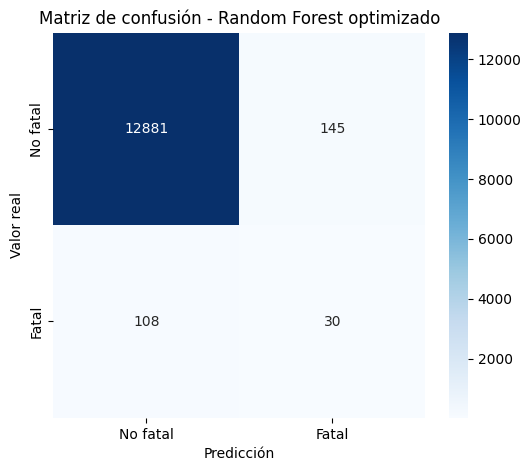

In [28]:
# Visualización de la matriz de confusión

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No fatal", "Fatal"],
    yticklabels=["No fatal", "Fatal"]
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión - Random Forest optimizado")

plt.show()

|               | Predicción No fatal | Predicción Fatal |
| ------------- | ------------------: | ---------------: |
| Real No fatal |               12880 |              145 |
| Real Fatal    |                 108 |               30 |



La matriz de confusión muestra que el modelo identifica correctamente la gran mayoría de los siniestros no fatales, lo cual es esperable debido al fuerte predominio de esta clase en el dataset.

Para la clase fatal, el modelo logra detectar correctamente 30 casos sobre 138 siniestros fatales reales, mientras que 108 casos fatales no fueron identificados. Además, genera 145 falsas alarmas, es decir, casos no fatales clasificados como fatales.

Estos resultados muestran que el modelo logra capturar parte de los patrones asociados a siniestros fatales, aunque todavía presenta limitaciones importantes para detectar todos los casos positivos.

### **10. Interpretación del Random Forest optimizado**

Además de evaluar el desempeño predictivo del modelo, resulta importante comprender qué variables contribuyen en mayor medida a la clasificación de los siniestros.

En los modelos basados en árboles es posible estimar la importancia relativa de cada variable, lo que permite identificar cuáles fueron los factores más relevantes para la detección de siniestros fatales.

In [29]:
# Importancia de variables del Random Forest optimizado

import pandas as pd

feature_names = best_forest.named_steps[
    "preprocessor"
].get_feature_names_out()

importancias = best_forest.named_steps[
    "model"
].feature_importances_

df_importancias = (
    pd.DataFrame({
        "variable": feature_names,
        "importancia": importancias
    })
    .sort_values(
        by="importancia",
        ascending=False
    )
)

df_importancias.head(20)

,variable,importancia
2,num__edad_promedio_victimas,0.073437
147,cat__tipo_de_via_siniestro_nan,0.058688
352,cat__sexo_victima_agregado_SD,0.052702
0,num__latitud_siniestro,0.047540
1,num__longitud_siniestro,0.038351
328,cat__modo_desplazamiento_victima_PEATON,0.036511
344,cat__contraparte_siniestro_SD,0.031057
329,cat__modo_desplazamiento_victima_SD,0.028757
350,cat__sexo_victima_agregado_M,0.026215
275,cat__participantes_siniestro_SD-SD,0.023191


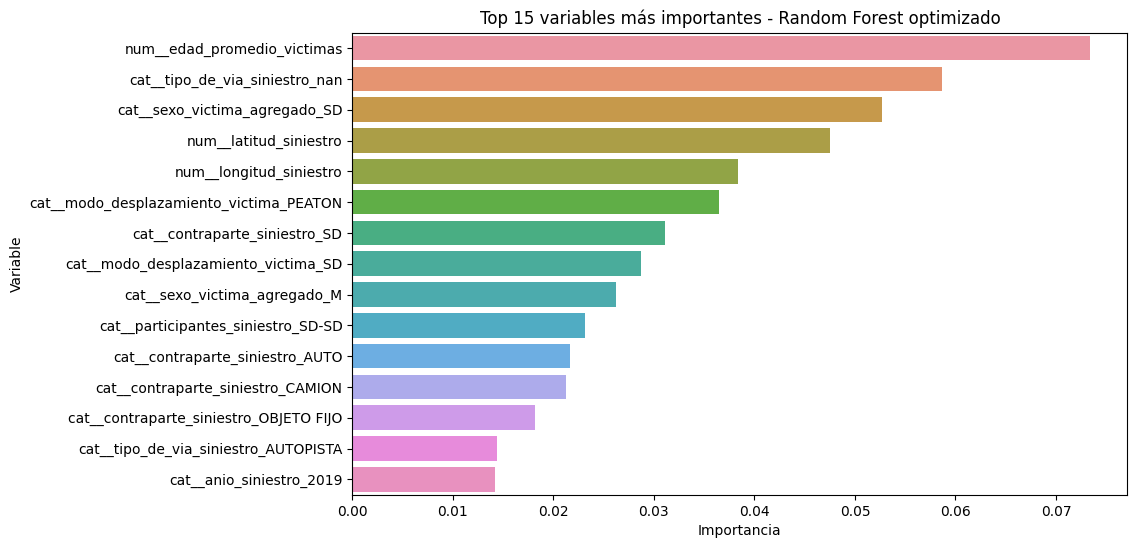

In [30]:
# Top 15 variables más importantes

top_importancias = df_importancias.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_importancias,
    x="importancia",
    y="variable"
)

plt.title("Top 15 variables más importantes - Random Forest optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

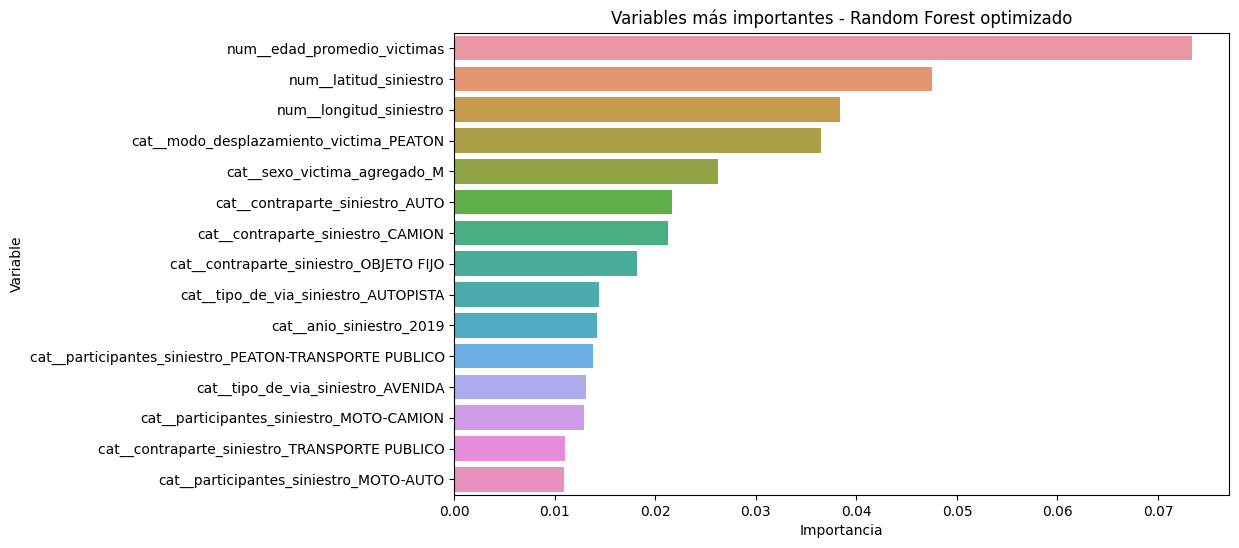

In [31]:
# Top variables más importantes (sin categorías de datos faltantes)

df_importancias_limpio = df_importancias[
    ~df_importancias["variable"].str.contains(
        "SD|SIN_DATO|nan",
        case=False,
        na=False
    )
]

top_importancias_limpio = df_importancias_limpio.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_importancias_limpio,
    x="importancia",
    y="variable"
)

plt.title("Variables más importantes - Random Forest optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable")

plt.show()

El gráfico anterior muestra las categorías individuales con mayor importancia dentro del modelo.

Sin embargo, varias variables categóricas fueron transformadas mediante One Hot Encoding durante el preprocesamiento. Como consecuencia, una misma variable original puede quedar representada por múltiples columnas independientes, distribuyendo su importancia entre distintas categorías.

Por este motivo, resulta conveniente complementar el análisis agrupando las importancias de todas las categorías pertenecientes a una misma variable original, con el objetivo de identificar cuáles fueron los factores generales más relevantes para la clasificación de los siniestros.

In [32]:
# Importancia de categorías asociadas a día de semana y rango horario que no se visualizan entre las más importantes

df_importancias[
    df_importancias["variable"].str.contains(
        "rango_horario|dia_semana",
        case=False,
        na=False
    )
].sort_values(
    by="importancia",
    ascending=False
)

,variable,importancia
57,cat__dia_semana_Thursday,6.161085e-03
53,cat__dia_semana_Friday,5.946416e-03
59,cat__dia_semana_Wednesday,5.501273e-03
54,cat__dia_semana_Monday,5.279341e-03
58,cat__dia_semana_Tuesday,5.186189e-03
55,cat__dia_semana_Saturday,4.972161e-03
56,cat__dia_semana_Sunday,4.700860e-03
95,cat__rango_horario_3.0,3.401130e-03
99,cat__rango_horario_5.0,3.284447e-03
74,cat__rango_horario_15,2.615923e-03


Durante el EDA se identificaron diferencias relevantes en la proporción de siniestros fatales según el día de la semana y el horario de ocurrencia.

La tabla anterior muestra que estas variables continúan aportando información al modelo. Sin embargo, al haber sido transformadas mediante One Hot Encoding, su importancia quedó distribuida entre múltiples categorías, lo que dificulta que aparezcan destacadas en los rankings generales de variables individuales.

Este resultado refuerza la coherencia entre los hallazgos obtenidos durante el análisis exploratorio y los patrones utilizados posteriormente por el modelo predictivo.

**Cierre de la interpretación del modelo**

En conjunto, el análisis de importancia de variables muestra que el modelo utiliza información demográfica, espacial, temporal y contextual para identificar siniestros fatales.

Entre los factores más relevantes aparecen la edad promedio de las víctimas, la ubicación geográfica del siniestro, el modo de desplazamiento, el tipo de vía y la contraparte involucrada.

Asimismo, el análisis específico de las variables temporales permitió verificar que los patrones observados durante el EDA continúan presentes en el modelo, aunque distribuidos entre múltiples categorías debido al proceso de One Hot Encoding.

La consistencia observada entre los hallazgos exploratorios y las variables utilizadas por el modelo aporta evidencia adicional sobre la validez de los patrones identificados a lo largo del proyecto.

**Conclusiones**

En conjunto, el análisis de importancia de variables muestra que el modelo utiliza información demográfica, espacial, temporal y contextual para identificar siniestros fatales.

Entre los factores más relevantes aparecen la edad promedio de las víctimas, la ubicación geográfica del siniestro, el modo de desplazamiento, el tipo de vía y la contraparte involucrada.

Asimismo, el análisis específico de las variables temporales permitió verificar que los patrones observados durante el EDA continúan presentes en el modelo, aunque distribuidos entre múltiples categorías debido al proceso de One Hot Encoding.

La consistencia observada entre los hallazgos exploratorios y las variables utilizadas por el modelo aporta evidencia adicional sobre la validez de los patrones identificados a lo largo del proyecto.

### **11. Análisis de estabilidad del modelo**

Los algoritmos de Machine Learning que incorporan procesos aleatorios pueden producir resultados ligeramente diferentes dependiendo de la semilla utilizada durante el entrenamiento y la partición de los datos.

Con el objetivo de evaluar la robustez del modelo seleccionado, se realiza un análisis de estabilidad utilizando distintas semillas aleatorias. Esto permite verificar si el desempeño observado para el Random Forest optimizado se mantiene de forma consistente o si depende significativamente de una configuración particular.

In [33]:
for col in ["rango_horario", "comuna_siniestro"]:
    print("\n", col)
    print(
        X[col]
        .apply(lambda x: type(x).__name__)
        .value_counts()
    )


 rango_horario
rango_horario
float    32830
str      32706
int        282
Name: count, dtype: int64

 comuna_siniestro
comuna_siniestro
float    33924
str      31894
Name: count, dtype: int64


In [34]:
# Durante el análisis de estabilidad del modelo se detectó que algunas variables categóricas presentaban valores almacenados con distintos tipos de datos (string, entero y flotante).
# Con el objetivo de garantizar la consistencia del proceso de codificación y permitir la reproducibilidad de los experimentos, se unificaron los tipos de datos de dichas variables antes de continuar con las evaluaciones.

# Homogeneización de variables categóricas

X["rango_horario"] = X["rango_horario"].astype(str)
X["comuna_siniestro"] = X["comuna_siniestro"].astype(str)

C:\Users\consul_05\AppData\Local\Temp\ipykernel_332\3335832931.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["rango_horario"] = X["rango_horario"].astype(str)
C:\Users\consul_05\AppData\Local\Temp\ipykernel_332\3335832931.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["comuna_siniestro"] = X["comuna_siniestro"].astype(str)


In [35]:
# Verificación de tipos de datos unificados

for col in ["rango_horario", "comuna_siniestro"]:
    print("\n", col)
    print(
        X[col]
        .apply(lambda x: type(x).__name__)
        .value_counts()
    )


 rango_horario
rango_horario
str    65818
Name: count, dtype: int64

 comuna_siniestro
comuna_siniestro
str    65818
Name: count, dtype: int64


In [36]:
# Evaluación de estabilidad utilizando distintas semillas

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

semillas = [42, 7, 123, 2025, 999]

resultados_semillas = []

for semilla in semillas:

    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=semilla
    )

    pipeline_rf = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            (
                "model",
                RandomForestClassifier(
                    n_estimators=200,
                    max_depth=None,
                    min_samples_leaf=5,
                    class_weight="balanced",
                    random_state=semilla,
                    n_jobs=-1
                )
            )
        ]
    )

    pipeline_rf.fit(X_train_s, y_train_s)

    y_pred_s = pipeline_rf.predict(X_test_s)

    resultados_semillas.append({
        "semilla": semilla,
        "precision": round(
            precision_score(y_test_s, y_pred_s, zero_division=0), 4
        ),
        "recall": round(
            recall_score(y_test_s, y_pred_s, zero_division=0), 4
        ),
        "f1_score": round(
            f1_score(y_test_s, y_pred_s, zero_division=0), 4
        )
    })

df_semillas = pd.DataFrame(resultados_semillas)

df_semillas

,semilla,precision,recall,f1_score
0,42,0.1706,0.2101,0.1883
1,7,0.2439,0.2899,0.2649
2,123,0.2135,0.2754,0.2405
3,2025,0.2216,0.2681,0.2426
4,999,0.2368,0.2609,0.2483


Los resultados muestran que el desempeño del modelo presenta cierta variabilidad frente a cambios en la semilla aleatoria utilizada para la partición de los datos.

Sin embargo, en todas las corridas el modelo mantuvo capacidad para detectar siniestros fatales y obtuvo valores de F1-Score superiores a los observados en los modelos alternativos evaluados durante el proyecto.

El F1-Score osciló entre 0,188 y 0,265, con un valor promedio cercano a 0,237. Estos resultados sugieren que el Random Forest optimizado mantiene un desempeño consistente, aunque moderadamente sensible a la composición específica de los conjuntos de entrenamiento y prueba, situación esperable dada la fuerte desproporción entre clases presente en el dataset.

### **12. Conclusiones**

El objetivo de esta fase fue construir y evaluar modelos predictivos capaces de identificar siniestros fatales a partir de la información disponible en el dataset consolidado de siniestros viales de la Ciudad Autónoma de Buenos Aires.

Debido al fuerte desbalance de clases presente en los datos, se utilizaron métricas orientadas a la detección de la clase minoritaria, priorizando especialmente Precision, Recall y F1-Score por sobre Accuracy.

Se evaluaron distintos enfoques de modelado, incluyendo Dummy Classifier, Logistic Regression, Decision Tree y Random Forest. Posteriormente se realizó un proceso de optimización de hiperparámetros mediante GridSearchCV para los modelos con mejor desempeño inicial.

El modelo seleccionado fue Random Forest optimizado, ya que obtuvo el mejor equilibrio entre precisión y capacidad de detección de siniestros fatales. Además, el análisis de estabilidad realizado con múltiples semillas mostró que el modelo mantiene un desempeño consistente frente a diferentes particiones de los datos.

El análisis de importancia de variables permitió identificar que factores demográficos, espaciales, temporales y contextuales contribuyen a la clasificación de los siniestros, observándose coherencia entre los patrones detectados durante el EDA y las variables utilizadas por el modelo.

Si bien el desempeño alcanzado aún presenta margen de mejora, los resultados obtenidos demuestran que es posible detectar parcialmente patrones asociados a la ocurrencia de siniestros fatales utilizando exclusivamente la información disponible en el dataset analizado.

### **Limitaciones y mejoras futuras**

El principal desafío del problema abordado es el fuerte desbalance entre clases, ya que los siniestros fatales representan aproximadamente el 1% del total de registros disponibles. Esta situación limita la capacidad de aprendizaje de los modelos y dificulta la detección de casos positivos.

Como posibles líneas de mejora futuras podrían explorarse técnicas adicionales para el tratamiento de clases desbalanceadas, incorporar nuevas fuentes de información relevantes para la ocurrencia de siniestros y evaluar algoritmos más avanzados de clasificación.

Asimismo, durante el análisis de importancia de variables se observó que algunas variables temporales, como el horario del siniestro, distribuyen su importancia entre múltiples categorías generadas mediante One Hot Encoding. Como posible mejora futura, podría evaluarse la construcción de franjas horarias más amplias (por ejemplo: madrugada, mañana, mediodía, tarde, noche y trasnoche), facilitando la interpretación de los resultados y potencialmente mejorando la capacidad predictiva del modelo.